In [65]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from aispy.psmap import load_psmap, PSMAPSurrogate

import sys, os
sys.path.insert(0, os.path.expanduser('~/local/aispy'))

In [66]:
# start by getting the psmaps
psmap = load_psmap('../output-files/PSGRID4D_CONFOCAL_FINE_Z100.h5')

In [67]:
surrogate = PSMAPSurrogate(psmap, t_det=3.8, use_gpu=True)
print(surrogate._dx)
x = np.linspace(-4e-4, 4e-4, 100)
y = x
X, Y = np.meshgrid(x,y)
V = np.zeros_like(X)

5.9999999999999995e-05


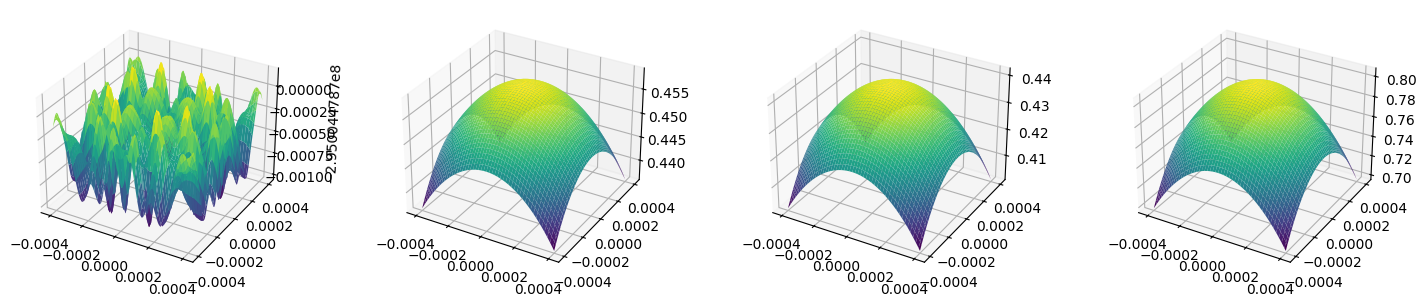

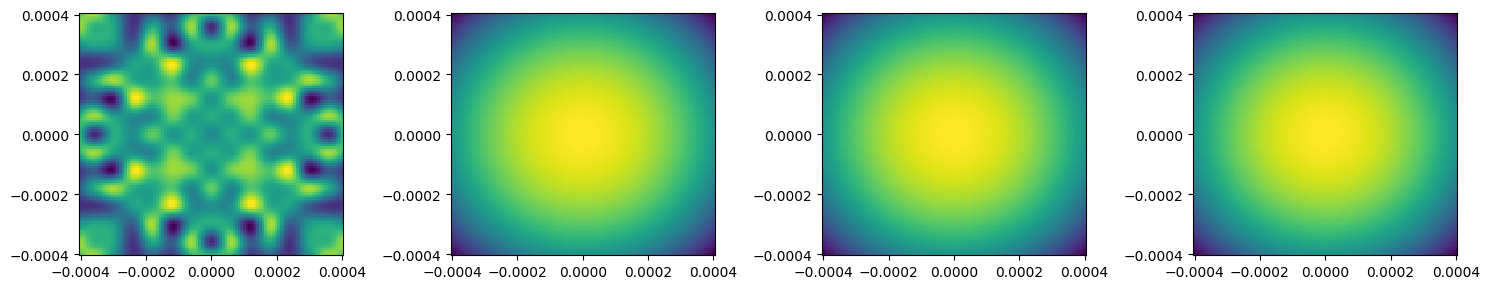

In [68]:
# X0 vs Y0
dphi, a0, a1 = surrogate.eval(X.flatten(),Y.flatten(),V.flatten(),V.flatten())
dphi = dphi[:,0].reshape(X.shape) 
a0 = a0[:,0].reshape(X.shape)
a1 = a1[:,0].reshape(X.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
ax[0].plot_surface(X,Y,dphi, cmap="viridis")
ax[1].plot_surface(X,Y,a0, cmap="viridis")
ax[2].plot_surface(X,Y,a1, cmap="viridis")
ax[3].plot_surface(X,Y,a0**2+a1**2+2*a0*a1*np.cos(dphi), cmap="viridis")

fig.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].pcolormesh(X,Y,dphi)
ax[1].pcolormesh(X,Y,a0)
ax[2].pcolormesh(X,Y,a1)
ax[3].pcolormesh(X,Y,a0**2+a1**2+2*a0*a1*np.cos(dphi))

fig.tight_layout()

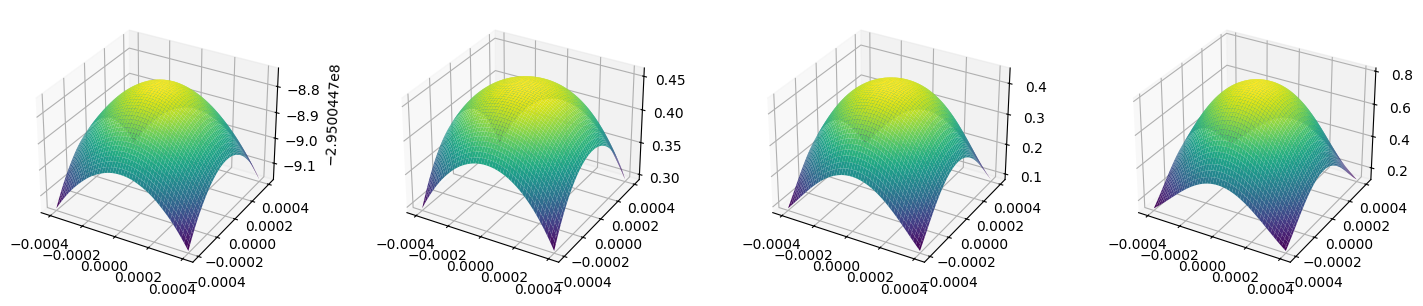

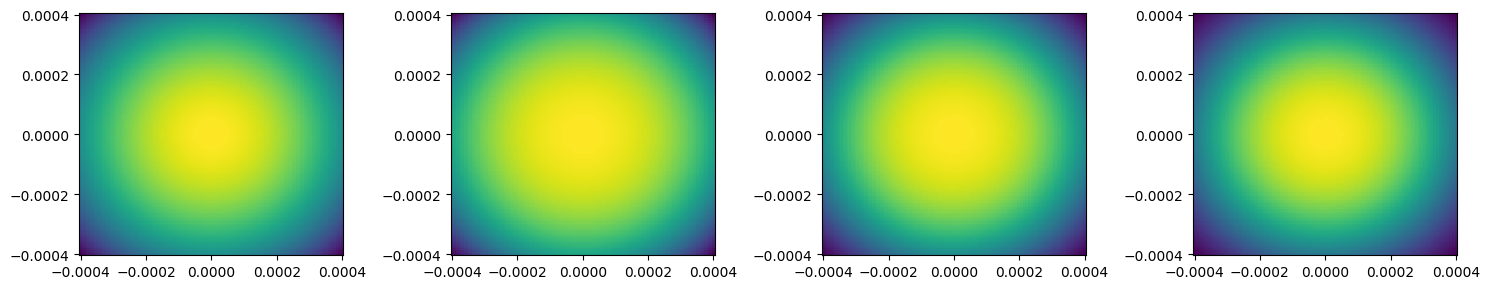

In [69]:
# VX0 vs VY0
dphi, a0, a1 = surrogate.eval(V.flatten(),V.flatten(),X.flatten(),Y.flatten())
dphi = dphi[:,0].reshape(X.shape) 
a0 = a0[:,0].reshape(X.shape)
a1 = a1[:,0].reshape(X.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
ax[0].plot_surface(X,Y,dphi, cmap="viridis")
ax[1].plot_surface(X,Y,a0, cmap="viridis")
ax[2].plot_surface(X,Y,a1, cmap="viridis")
ax[3].plot_surface(X,Y,a0**2+a1**2+2*a0*a1*np.cos(dphi), cmap="viridis")

fig.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].pcolormesh(X,Y,dphi)
ax[1].pcolormesh(X,Y,a0)
ax[2].pcolormesh(X,Y,a1)
ax[3].pcolormesh(X,Y,a0**2+a1**2+2*a0*a1*np.cos(dphi))

fig.tight_layout()

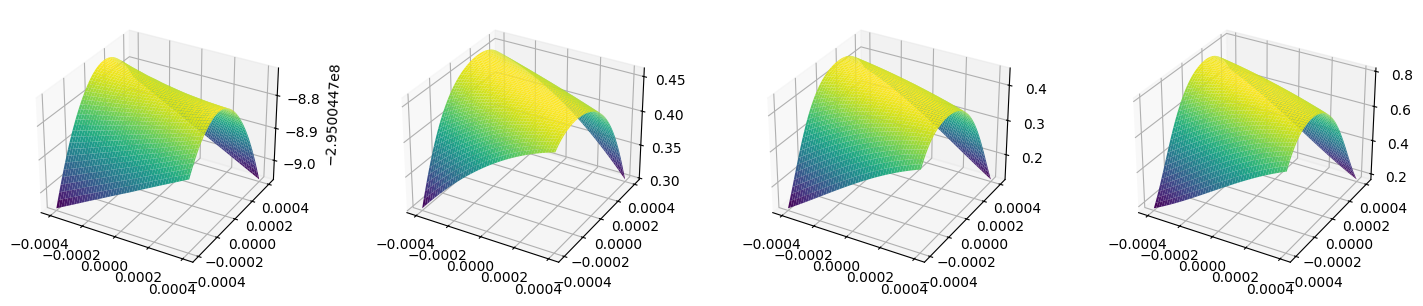

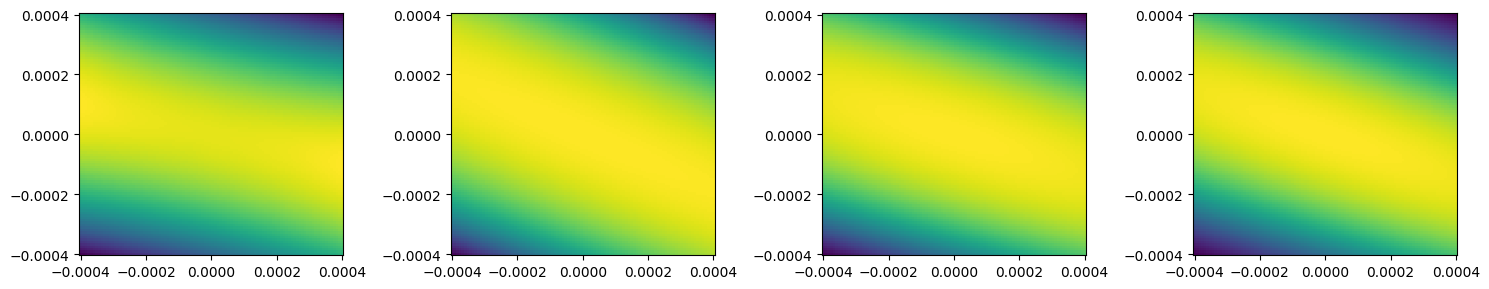

In [87]:
# X0 vs VX0
dphi, a0, a1 = surrogate.eval(X.flatten(),V.flatten(),Y.flatten(),V.flatten())
dphi = dphi[:,0].reshape(X.shape) + 0 * (X + Y*3.8)
a0 = a0[:,0].reshape(X.shape)
a1 = a1[:,0].reshape(X.shape)
prob = a0**2+a1**2+2*a0*a1*np.cos(dphi)

fig, ax = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
ax[0].plot_surface(X,Y,dphi, cmap="viridis")
ax[1].plot_surface(X,Y,a0, cmap="viridis")
ax[2].plot_surface(X,Y,a1, cmap="viridis")
ax[3].plot_surface(X,Y,prob, cmap="viridis")

fig.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].pcolormesh(X,Y,dphi)
ax[1].pcolormesh(X,Y,a0)
ax[2].pcolormesh(X,Y,a1)
ax[3].pcolormesh(X,Y,prob)

fig.tight_layout()

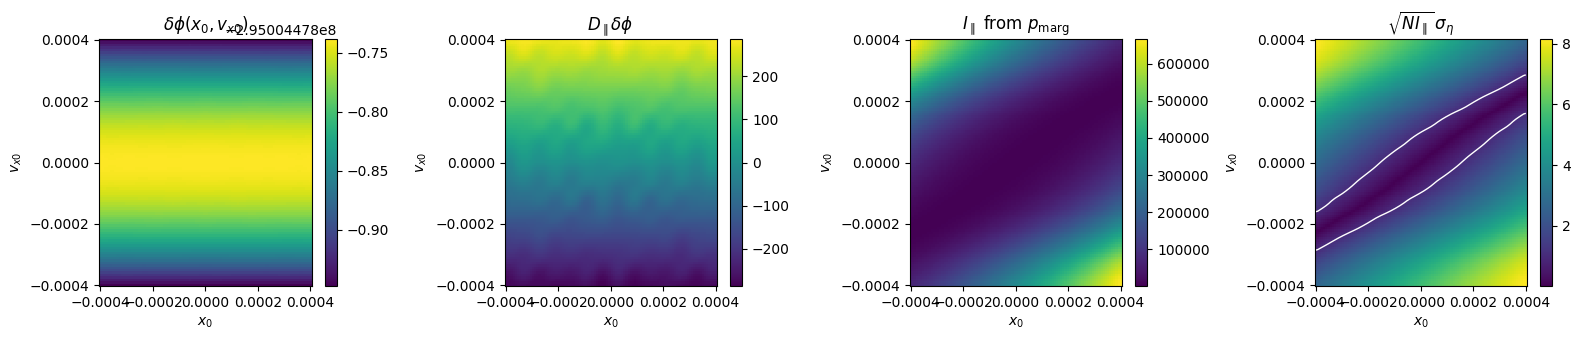

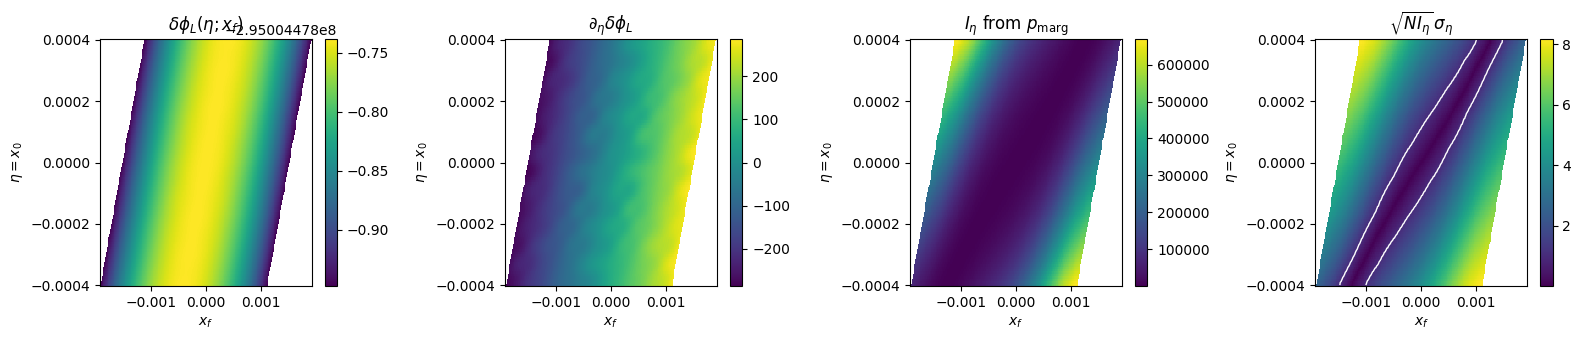

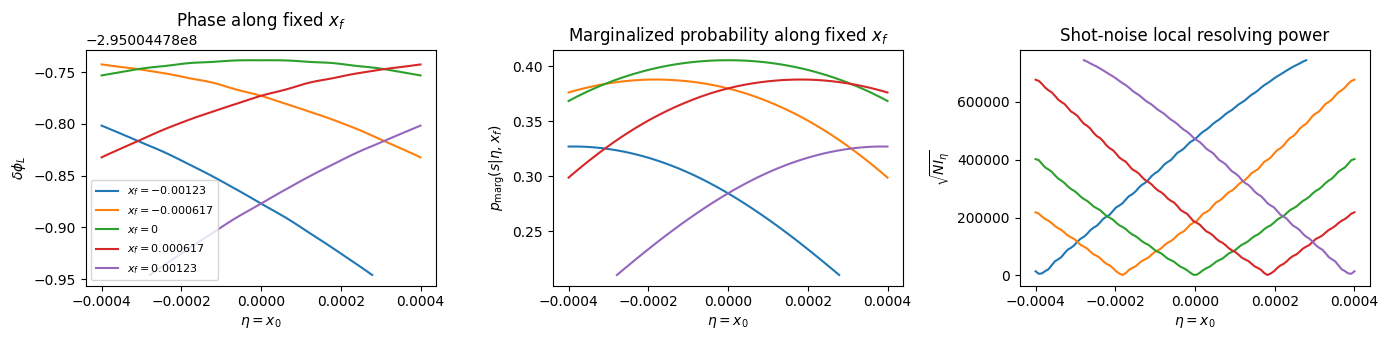

In [ ]:
# Degeneracy-breaking diagnostics along ballistic lines x_f = x0 + vx0 * t_d
# Includes marginalization over random common phase theta.

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# -----------------------------
# User parameters
# -----------------------------
t_d = 3.8
N_atoms = 1e6
sigma_eta = 10e-6

n_theta = 512
theta_grid = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
theta_weights = np.ones(n_theta) / n_theta

eps = 1e-12

# -----------------------------
# Marginalize probability over theta
# -----------------------------
# Conditional probability:
# p(s|x0,vx0,theta) = a0^2 + a1^2 + 2 a0 a1 cos(dphi + theta)
#
# Marginalized probability:
# p_marg(s|x0,vx0) = int dtheta p(theta) p(s|x0,vx0,theta)

prob_theta = (
    a0[None, :, :]**2
    + a1[None, :, :]**2
    + 2*a0[None, :, :]*a1[None, :, :]*np.cos(dphi[None, :, :] + theta_grid[:, None, None]))


prob = np.tensordot(theta_weights, prob_theta, axes=(0, 0))

# For uniform theta, this should be almost exactly a0^2 + a1^2.
# print(np.nanmax(np.abs(prob - (a0**2 + a1**2))))

# -----------------------------
# Extract 1D axes from meshgrid
# Assumes X.shape == Y.shape == (len(vx0_axis), len(x0_axis))
# -----------------------------
x0_axis = X[0, :]
vx0_axis = Y[:, 0]

# If dphi is wrapped, unwrap before differentiating raw phase.
# The probability/Fisher diagnostic below uses marginalized prob.
dphi_unwrapped = dphi#np.unwrap(np.unwrap(dphi, axis=0), axis=1)

# -----------------------------
# 1. Local derivative in original (x0, vx0) coordinates
# D_parallel = d/dx0 - (1/t_d) d/dvx0
# -----------------------------
ddphi_dvx0, ddphi_dx0 = np.gradient(dphi_unwrapped, vx0_axis, x0_axis)
G_phi = ddphi_dx0 - ddphi_dvx0 / t_d

dprob_dvx0, dprob_dx0 = np.gradient(prob, vx0_axis, x0_axis)
G_prob = dprob_dx0 - dprob_dvx0 / t_d

# Fisher information along ballistic degeneracy direction.
# Binary readout: p = prob, 1-p = other port.
p_clip = np.clip(prob, eps, 1 - eps)
I_parallel = G_prob**2 / (p_clip * (1 - p_clip))

SNR_parallel = np.sqrt(N_atoms * I_parallel)
if sigma_eta is not None:
    SNR_parallel = SNR_parallel * sigma_eta

# -----------------------------
# Plot original-space diagnostics
# -----------------------------
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))

im0 = ax[0].pcolormesh(X, Y, dphi, shading="auto")
ax[0].set_title(r"$\delta\phi(x_0,v_{x0})$")
ax[0].set_xlabel(r"$x_0$")
ax[0].set_ylabel(r"$v_{x0}$")
fig.colorbar(im0, ax=ax[0])

im1 = ax[1].pcolormesh(X, Y, G_phi, shading="auto")
ax[1].set_title(r"$D_\parallel \delta\phi$")
ax[1].set_xlabel(r"$x_0$")
ax[1].set_ylabel(r"$v_{x0}$")
fig.colorbar(im1, ax=ax[1])

im2 = ax[2].pcolormesh(X, Y, I_parallel, shading="auto")
ax[2].set_title(r"$I_\parallel$ from $p_{\rm marg}$")
ax[2].set_xlabel(r"$x_0$")
ax[2].set_ylabel(r"$v_{x0}$")
fig.colorbar(im2, ax=ax[2])

im3 = ax[3].pcolormesh(X, Y, SNR_parallel, shading="auto")
if sigma_eta is None:
    ax[3].set_title(r"$\sqrt{N I_\parallel}$")
else:
    ax[3].set_title(r"$\sqrt{N I_\parallel}\,\sigma_\eta$")
ax[3].contour(X, Y, SNR_parallel, levels=[1], colors="w", linewidths=1)
ax[3].set_xlabel(r"$x_0$")
ax[3].set_ylabel(r"$v_{x0}$")
fig.colorbar(im3, ax=ax[3])

fig.tight_layout()
plt.show()

# -----------------------------
# 2. Transform to (eta=x0, x_f) coordinates
# -----------------------------
xf_grid = X + Y * t_d

xf_min = np.nanmin(xf_grid)
xf_max = np.nanmax(xf_grid)

xf_axis = np.linspace(xf_min, xf_max, 250)
eta_axis = x0_axis.copy()

ETA, XF = np.meshgrid(eta_axis, xf_axis, indexing="ij")
VX_LINE = (XF - ETA) / t_d

# Interpolators use axis order (vx0, x0), because arrays have shape (nvx, nx)
interp_dphi = RegularGridInterpolator(
    (vx0_axis, x0_axis),
    dphi_unwrapped,
    bounds_error=False,
    fill_value=np.nan,
)

interp_prob = RegularGridInterpolator(
    (vx0_axis, x0_axis),
    prob,
    bounds_error=False,
    fill_value=np.nan,
)

pts = np.column_stack([VX_LINE.ravel(), ETA.ravel()])

dphi_L = interp_dphi(pts).reshape(ETA.shape)
prob_L = interp_prob(pts).reshape(ETA.shape)

# Derivative along ballistic line, i.e. d/deta at fixed x_f
G_phi_L = np.gradient(dphi_L, eta_axis, axis=0)
G_prob_L = np.gradient(prob_L, eta_axis, axis=0)

pL_clip = np.clip(prob_L, eps, 1 - eps)
I_eta = G_prob_L**2 / (pL_clip * (1 - pL_clip))

SNR_eta = np.sqrt(N_atoms * I_eta)
if sigma_eta is not None:
    SNR_eta = SNR_eta * sigma_eta

# -----------------------------
# Plot line-coordinate diagnostics
# -----------------------------
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))

im0 = ax[0].pcolormesh(XF, ETA, dphi_L, shading="auto")
ax[0].set_title(r"$\delta\phi_L(\eta;x_f)$")
ax[0].set_xlabel(r"$x_f$")
ax[0].set_ylabel(r"$\eta=x_0$")
fig.colorbar(im0, ax=ax[0])

im1 = ax[1].pcolormesh(XF, ETA, G_phi_L, shading="auto")
ax[1].set_title(r"$\partial_\eta \delta\phi_L$")
ax[1].set_xlabel(r"$x_f$")
ax[1].set_ylabel(r"$\eta=x_0$")
fig.colorbar(im1, ax=ax[1])

im2 = ax[2].pcolormesh(XF, ETA, I_eta, shading="auto")
ax[2].set_title(r"$I_\eta$ from $p_{\rm marg}$")
ax[2].set_xlabel(r"$x_f$")
ax[2].set_ylabel(r"$\eta=x_0$")
fig.colorbar(im2, ax=ax[2])

im3 = ax[3].pcolormesh(XF, ETA, SNR_eta, shading="auto")
if sigma_eta is None:
    ax[3].set_title(r"$\sqrt{N I_\eta}$")
else:
    ax[3].set_title(r"$\sqrt{N I_\eta}\,\sigma_\eta$")
ax[3].contour(XF, ETA, SNR_eta, levels=[1], colors="w", linewidths=1)
ax[3].set_xlabel(r"$x_f$")
ax[3].set_ylabel(r"$\eta=x_0$")
fig.colorbar(im3, ax=ax[3])

fig.tight_layout()
plt.show()

# -----------------------------
# 3. Line cuts at fixed x_f
# -----------------------------
n_lines = 5
xf_values = np.linspace(
    np.nanpercentile(xf_grid, 10),
    np.nanpercentile(xf_grid, 90),
    n_lines,
)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))

for xf0 in xf_values:
    vx_line = (xf0 - eta_axis) / t_d
    pts_line = np.column_stack([vx_line, eta_axis])

    dphi_line = interp_dphi(pts_line)
    prob_line = interp_prob(pts_line)

    valid = np.isfinite(dphi_line) & np.isfinite(prob_line)

    if np.sum(valid) < 3:
        continue

    eta_valid = eta_axis[valid]
    dphi_line = dphi_line[valid]
    prob_line = prob_line[valid]

    G_prob_line = np.gradient(prob_line, eta_valid)

    p_line_clip = np.clip(prob_line, eps, 1 - eps)
    I_line = G_prob_line**2 / (p_line_clip * (1 - p_line_clip))

    ax[0].plot(eta_valid, dphi_line, label=fr"$x_f={xf0:.3g}$")
    ax[1].plot(eta_valid, prob_line)
    ax[2].plot(eta_valid, np.sqrt(N_atoms * I_line))

ax[0].set_title(r"Phase along fixed $x_f$")
ax[0].set_xlabel(r"$\eta=x_0$")
ax[0].set_ylabel(r"$\delta\phi_L$")
ax[0].legend(fontsize=8)

ax[1].set_title(r"Marginalized probability along fixed $x_f$")
ax[1].set_xlabel(r"$\eta=x_0$")
ax[1].set_ylabel(r"$p_{\rm marg}(s|\eta,x_f)$")

ax[2].set_title(r"Shot-noise local resolving power")
ax[2].set_xlabel(r"$\eta=x_0$")
ax[2].set_ylabel(r"$\sqrt{N I_\eta}$")

fig.tight_layout()
plt.show()

# Interpretation:
# - D_parallel dphi ~ 0 means raw phase is locally flat along ballistic degeneracy lines.
# - I_parallel ~ 0 means the theta-marginalized probability is locally uninformative.
# - sqrt(N I_parallel) * sigma_eta <~ 1 means the variation is not resolvable over width sigma_eta.

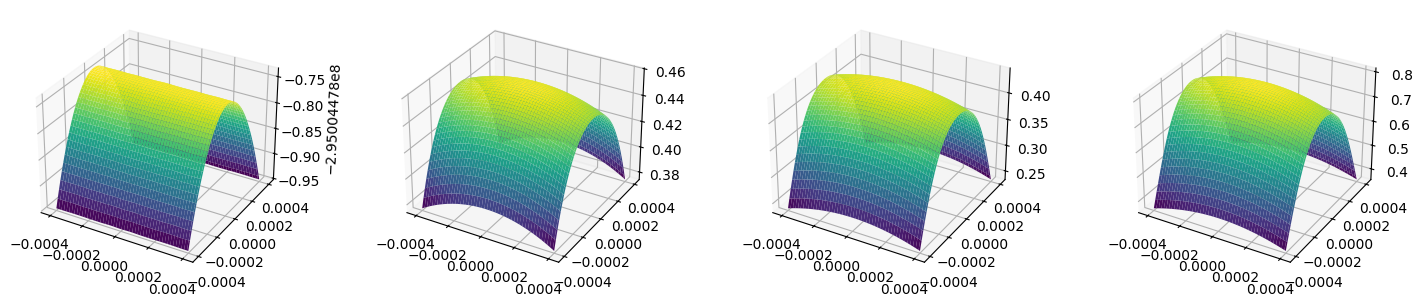

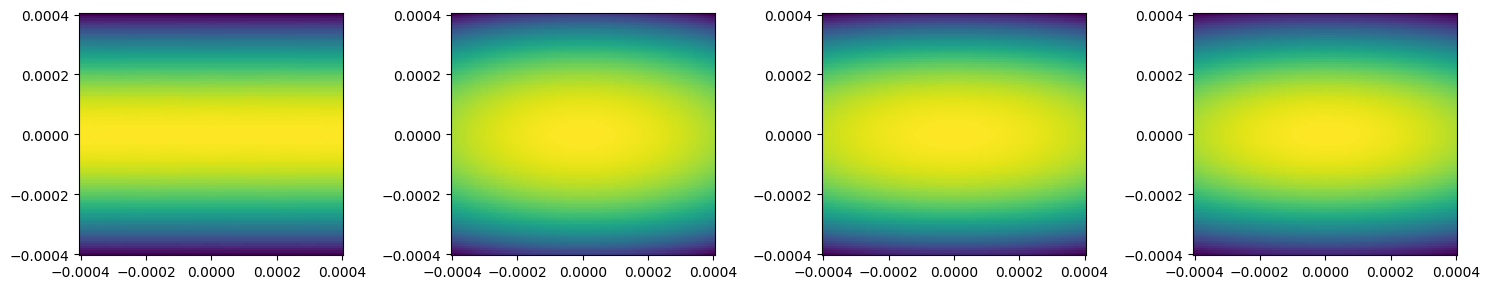

In [89]:
# X0 vs VY0
dphi, a0, a1 = surrogate.eval(X.flatten(),V.flatten(),V.flatten(),Y.flatten())
dphi = dphi[:,0].reshape(X.shape)
a0 = a0[:,0].reshape(X.shape)
a1 = a1[:,0].reshape(X.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
ax[0].plot_surface(X,Y,dphi, cmap="viridis")
ax[1].plot_surface(X,Y,a0, cmap="viridis")
ax[2].plot_surface(X,Y,a1, cmap="viridis")
ax[3].plot_surface(X,Y,a0**2+a1**2+2*a0*a1*np.cos(dphi), cmap="viridis")

fig.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].pcolormesh(X,Y,dphi)
ax[1].pcolormesh(X,Y,a0)
ax[2].pcolormesh(X,Y,a1)
ax[3].pcolormesh(X,Y,a0**2+a1**2+2*a0*a1*np.cos(dphi))

fig.tight_layout()